In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F

In [8]:
IMG_SIZE = 224

transform =transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])

])

In [9]:
dataset = datasets.ImageFolder(root="/home/nsk/PROJECT/images/data", transform=transform)

In [10]:
dataset

Dataset ImageFolder
    Number of datapoints: 7553
    Root location: /home/nsk/PROJECT/images/data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [11]:
Batch_size =32

dataloader = DataLoader(dataset, batch_size=Batch_size, shuffle=True)


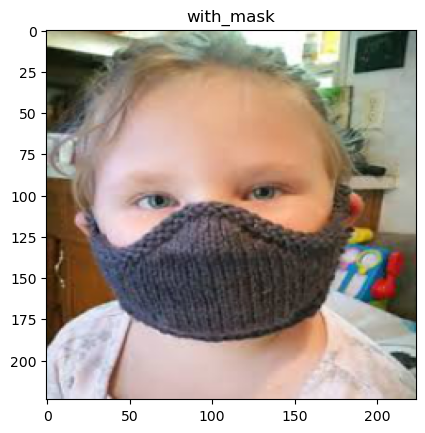

In [24]:
def imshow(img,label):
    img = img / 2 +0.5
    npimg =img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.title(label)
    plt.show()

dataiter = iter(dataloader)
images, label = next(dataiter)

imshow(images[0],dataset.classes[label[0]])

In [30]:
class CustomModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool= nn.MaxPool2d(2,2)

        self.fc1= nn.Linear(200704,128)
        self.fc2 =nn.Linear(128,2)
    
    def forward(self, x):
        x =self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x =self.fc2(x)
        return x

In [31]:
model =CustomModel()
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
epochs =2

for epoch in range(epochs):
    total_loss=0
    model.train()
    for images, label in dataloader:
        outputs =model(images)

        loss = criterion(outputs, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+= loss.item()
    
    print(f"Epoch {epoch+1}/ {epochs} +++ >> Loss : {total_loss/len(dataloader):.4f}")


In [ ]:
    ``